<a href="https://colab.research.google.com/github/BOINI-VAMSHIKRISHNA/Deep-Learning/blob/main/minst_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from tensorflow.keras.datasets import mnist

(train_data, train_labe1s),(test_data, test_labels)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
train_data.shape

(60000, 28, 28)

In [4]:
test_data.shape

(10000, 28, 28)

In [6]:
train_labe1s[0]

np.uint8(5)

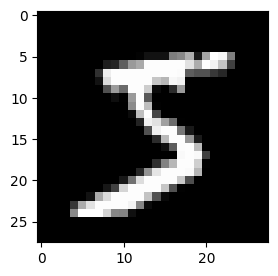

In [5]:
plt.figure(figsize = (5,3))
plt.imshow(train_data[0] , cmap = "gray")
plt.show()

In [8]:
train_data=train_data/255
test_data=test_data/255

In [11]:
import numpy as np
np.max(train_data[0])

np.float64(1.0)

In [12]:
train_data=train_data.reshape(60000,28*28)
test_data= test_data.reshape(10000,28*28)

In [13]:
train_data[0].shape

(784,)

In [14]:
np.unique(train_labe1s)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [15]:
np.unique(test_labels)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [17]:
from tensorflow.keras.utils import to_categorical

In [18]:
train_labe1s = to_categorical(train_labe1s)
test_labels = to_categorical(test_labels)

In [19]:
train_labe1s[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [22]:
#architechture

model=Sequential()
model.add(Dense(units=10, activation='relu', input_shape=(28*28,)))
model.add(Dense(units=12, activation='relu'))
model.add(Dense(units=10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,226 (63.39 KB)

 Trainable params: 8,112 (31.69 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,114 (31.70 KB)

In [26]:
model.compile(optimizer='rmsprop',
              loss="categorical_crossentropy",
              metrics=['accuracy'])

In [27]:
history=model.fit(train_data,train_labe1s,batch_size=64, epochs=10)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8291 - loss: 0.6109
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9044 - loss: 0.3318
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9154 - loss: 0.2905
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9231 - loss: 0.2697
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9267 - loss: 0.2553
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9294 - loss: 0.2466
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9323 - loss: 0.2381
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9336 - loss: 0.2310
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9363 - loss: 0.2251
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9370 - loss: 0.2201


In [29]:
history.history

{'accuracy': [0.8290500044822693,
  0.9044333100318909,
  0.9154000282287598,
  0.9230666756629944,
  0.9266833066940308,
  0.9293833374977112,
  0.9322666525840759,
  0.9336166381835938,
  0.9363333582878113,
  0.9369500279426575],
 'loss': [0.6109256744384766,
  0.3317697048187256,
  0.2904896140098572,
  0.26972004771232605,
  0.2553231418132782,
  0.2466137707233429,
  0.23814672231674194,
  0.23104748129844666,
  0.22508376836776733,
  0.22005435824394226]}

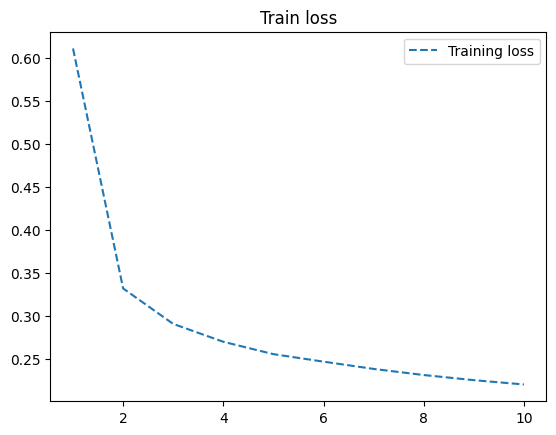

In [33]:
epoch= range(1,11)
plt.plot( epoch, history.history['loss'], "--", label = "Training loss")
plt.title("Train loss")
plt.legend()
plt.show()